In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

from explainerdashboard import ClassifierExplainer
from explainerdashboard import ExplainerDashboard

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# Load Final Dataset

output_path = "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Outputs/"

X_train = pd.read_csv(output_path + "X_train_final.csv")
X_test = pd.read_csv(output_path + "X_test_final.csv")

y_train = pd.read_csv(
    output_path + "y_train_final.csv"
).squeeze("columns")

y_test = pd.read_csv(
    output_path + "y_test_final.csv"
).squeeze("columns")

print("Datasets Loaded Successfully")

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)


Datasets Loaded Successfully

Training Shape : (12365, 44)
Testing Shape  : (3092, 44)


In [3]:
# Verify Dataset

print("="*60)
print("FINAL DATASET SUMMARY")
print("="*60)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("Features :", X_train.shape[1])

print("\nMissing Values")

print("Training :", X_train.isna().sum().sum())
print("Testing  :", X_test.isna().sum().sum())

print("\nTarget Distribution")

print("\nTraining")

print(round(y_train.value_counts(normalize=True)*100,2))

print("\nTesting")

print(round(y_test.value_counts(normalize=True)*100,2))


FINAL DATASET SUMMARY
Training Samples : 12365
Testing Samples  : 3092
Features : 44

Missing Values
Training : 0
Testing  : 0

Target Distribution

Training
Composite_CVD
0    92.71
1     7.29
Name: proportion, dtype: float64

Testing
Composite_CVD
0    92.72
1     7.28
Name: proportion, dtype: float64


In [4]:
# ==========================================================
# Handle Class Imbalance Using SMOTE
# ==========================================================

smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train
)

print("="*60)
print("AFTER SMOTE")
print("="*60)

print("Training Shape :", X_train_balanced.shape)

print("\nTarget Distribution")

print(y_train_balanced.value_counts())


AFTER SMOTE
Training Shape : (22928, 44)

Target Distribution
Composite_CVD
0    11464
1    11464
Name: count, dtype: int64


In [5]:
# ==========================================================
# Build SVM Model
# ==========================================================

svm_model = SVC(

    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42

)

print("SVM Model Created Successfully")

SVM Model Created Successfully


In [6]:
# ==========================================================
# Train SVM
# ==========================================================

svm_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("SVM Training Completed")

SVM Training Completed


In [7]:
# ==========================================================
# Predictions
# ==========================================================

y_pred_svm = svm_model.predict(X_test)

y_prob_svm = svm_model.predict_proba(X_test)[:,1]

In [8]:
# ==========================================================
# Performance Metrics
# ==========================================================

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_auc = roc_auc_score(y_test, y_prob_svm)
svm_mcc = matthews_corrcoef(y_test, y_pred_svm)
svm_kappa = cohen_kappa_score(y_test, y_pred_svm)

print("="*60)
print("SVM PERFORMANCE")
print("="*60)

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")
print(f"ROC AUC  : {svm_auc:.4f}")
print(f"MCC      : {svm_mcc:.4f}")
print(f"Kappa    : {svm_kappa:.4f}")

SVM PERFORMANCE
Accuracy : 0.7474
Precision: 0.2134
Recall   : 0.9200
F1 Score : 0.3464
ROC AUC  : 0.8886
MCC      : 0.3660
Kappa    : 0.2589


In [9]:
# ==========================================================
# Classification Report
# ==========================================================

print(classification_report(
    y_test,
    y_pred_svm
))

              precision    recall  f1-score   support

           0       0.99      0.73      0.84      2867
           1       0.21      0.92      0.35       225

    accuracy                           0.75      3092
   macro avg       0.60      0.83      0.59      3092
weighted avg       0.93      0.75      0.81      3092



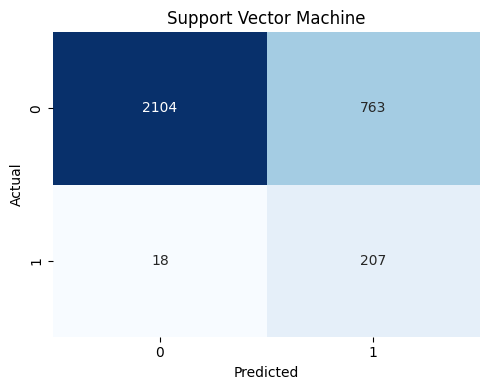

In [10]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Support Vector Machine")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

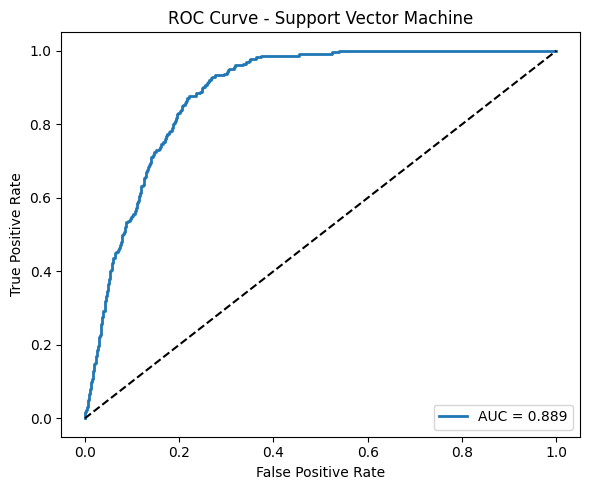

In [11]:
# ==========================================================
# ROC Curve
# ==========================================================

fpr, tpr, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {svm_auc:.3f}"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Support Vector Machine")

plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [12]:
model_path = "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Models/"

os.makedirs(model_path, exist_ok=True)

joblib.dump(
    svm_model,
    model_path + "SVM_Model.pkl"
)

['C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Models/SVM_Model.pkl']